### Connect to Kaggle

We will be using data available on Kaggle platform for this exercise. The data is available at https://www.kaggle.com/c/word2vec-nlp-tutorial/data.

Task to do https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews?resource=download

In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf
print(tf.__version__)

/opt/anaconda3/envs/mlproj/lib/python3.9/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/opt/anaconda3/envs/mlproj/lib/python3.9/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/opt/anaconda3/envs/mlproj/lib/python3.9/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to

: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. Import the dataset as pandas dataframe

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_table(r'/Users/anand/Desktop/LLM From Scratch/Demo/labeledTrainData.tsv')

In [3]:
df.shape

(25000, 3)

In [4]:
df.head()

,id,sentiment,review
0,5814_8,1,With all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi..."
2,7759_3,0,The film starts with a manager (Nicholas Bell)...
3,3630_4,0,It must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         25000 non-null  object
 1   sentiment  25000 non-null  int64 
 2   review     25000 non-null  object
dtypes: int64(1), object(2)
memory usage: 586.1+ KB


In [6]:
df['sentiment'].value_counts()

sentiment
1    12500
0    12500
Name: count, dtype: int64

In [7]:
df.loc[200, 'review']

'It takes patience to get through David Lynch\'s eccentric, but-- for a change-- life-affirming chronicle of Alvin Straight\'s journey, but stick with it. Though it moves as slow as Straight\'s John Deere, when he meets the kind strangers along his pilgrimage we learn much about the isolation of aging, the painful regrets and secrets, and ultimately the power of family and reconciliation. Richard Farnsworth caps his career with the year\'s most genuine performance, sad and poetic, flinty and caring. And Sissy Spacek matches him as his \\slow\\" daughter Rose who pines over her own private loss while caring for dad. Rarely has a modern film preached so positively about family."'

In [8]:
import re

def remove_tags(string):

    removelist = ""  # Add any characters you'd like to keep

    # Remove HTML tags

    result = re.sub(r'<[^>]+>', '', string)

    # Remove URLs

    result = re.sub(r'https?://\S+', '', result)

    # Remove non-alphanumeric characters (except for those in the removelist)

    result = re.sub(r'[^a-zA-Z0-9' + removelist + r'\s]', ' ', result)

    # Convert to lowercase

    result = result.lower()

    return result


In [9]:
remove_tags(df.loc[200, 'review'])

'it takes patience to get through david lynch s eccentric  but   for a change   life affirming chronicle of alvin straight s journey  but stick with it  though it moves as slow as straight s john deere  when he meets the kind strangers along his pilgrimage we learn much about the isolation of aging  the painful regrets and secrets  and ultimately the power of family and reconciliation  richard farnsworth caps his career with the year s most genuine performance  sad and poetic  flinty and caring  and sissy spacek matches him as his  slow   daughter rose who pines over her own private loss while caring for dad  rarely has a modern film preached so positively about family  '

In [10]:
df['clean_review']=df['review'].apply(lambda x: remove_tags(x))

In [11]:
df.head()

,id,sentiment,review,clean_review
0,5814_8,1,With all this stuff going down at the moment w...,with all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi...",the classic war of the worlds by timothy hi...
2,7759_3,0,The film starts with a manager (Nicholas Bell)...,the film starts with a manager nicholas bell ...
3,3630_4,0,It must be assumed that those who praised this...,it must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...,superbly trashy and wondrously unpretentious 8...


#### Split Data into Training and Test Data

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
df.head()

,id,sentiment,review,clean_review
0,5814_8,1,With all this stuff going down at the moment w...,with all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi...",the classic war of the worlds by timothy hi...
2,7759_3,0,The film starts with a manager (Nicholas Bell)...,the film starts with a manager nicholas bell ...
3,3630_4,0,It must be assumed that those who praised this...,it must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...,superbly trashy and wondrously unpretentious 8...


In [14]:
df_processed =  df[['clean_review','sentiment']].copy()

# def sent (text):
#   if text == 'positive':
#     return 1
#   else:
#     return 0

# df_processed['sentiment'] = df_processed['sentiment'].apply(lambda x : sent(x))
df_processed.head()

,clean_review,sentiment
0,with all this stuff going down at the moment w...,1
1,the classic war of the worlds by timothy hi...,1
2,the film starts with a manager nicholas bell ...,0
3,it must be assumed that those who praised this...,0
4,superbly trashy and wondrously unpretentious 8...,1


In [15]:
train, test = train_test_split(df_processed, test_size=0.2, random_state=42)

In [16]:
train.shape, test.shape

((20000, 2), (5000, 2))

In [17]:
train.head()

,clean_review,sentiment
23311,this movie is just plain dumb from the casting...,0
23623,dahmer a young confused man dahmer a confus...,0
1020,may the saints preserve us because this movie...,0
12645,the combination of reading the novella and vie...,1
1533,daniel day lewis in my left foot gives us one ...,1


In [18]:
train.reset_index(inplace=True, drop=True)
test.reset_index(inplace=True, drop=True)

In [19]:
train.head()

,clean_review,sentiment
0,this movie is just plain dumb from the casting...,0
1,dahmer a young confused man dahmer a confus...,0
2,may the saints preserve us because this movie...,0
3,the combination of reading the novella and vie...,1
4,daniel day lewis in my left foot gives us one ...,1


In [20]:
X_train = train['clean_review']
y_train = train['sentiment']
X_test = test['clean_review']
y_test = test['sentiment']

In [21]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(20000,)
(20000,)
(5000,)
(5000,)


### 2. Build the Tokenizer

In [ ]:
import tensorflow as tf

In [ ]:
desired_vocab_size = 30000
oov_tok = "<OOV>"
t = tf.keras.preprocessing.text.Tokenizer(num_words=desired_vocab_size, oov_token=oov_tok)

In [ ]:
#Fit tokenizer with actual training data
t.fit_on_texts(X_train.tolist())

In [ ]:
len(t.word_index)

69145

In [ ]:
#Vocabulary
print(t.word_index)

{'the': 1, 'and': 2, 'a': 3, 'of': 4, 'to': 5, 'is': 6, 'it': 7, 'in': 8, 'i': 9, 'this': 10, 'that': 11, 's': 12, 'was': 13, 'as': 14, 'movie': 15, 'for': 16, 'with': 17, 'but': 18, 'film': 19, 't': 20, 'on': 21, 'you': 22, 'not': 23, 'he': 24, 'his': 25, 'are': 26, 'have': 27, 'be': 28, 'one': 29, 'all': 30, 'at': 31, 'they': 32, 'by': 33, 'who': 34, 'an': 35, 'so': 36, 'from': 37, 'like': 38, 'there': 39, 'her': 40, 'or': 41, 'just': 42, 'about': 43, 'out': 44, 'has': 45, 'if': 46, 'what': 47, 'some': 48, 'good': 49, 'can': 50, 'more': 51, 'she': 52, 'when': 53, 'very': 54, 'up': 55, 'no': 56, 'even': 57, 'time': 58, 'my': 59, 'would': 60, 'which': 61, 'only': 62, 'story': 63, 'really': 64, 'see': 65, 'had': 66, 'their': 67, 'we': 68, 'me': 69, 'well': 70, 'were': 71, 'than': 72, 'much': 73, 'get': 74, 'been': 75, 'bad': 76, 'will': 77, 'people': 78, 'other': 79, 'also': 80, 'do': 81, 'into': 82, 'great': 83, 'first': 84, 'because': 85, 'him': 86, 'don': 87, 'how': 88, 'most': 89, '

# Prepare Training and Test Data

Get the word index for each of the word in the review

In [ ]:
X_train[0]

'this movie is just plain dumb from the casting of ralph meeker as mike hammer to the fatuous climax  the film is an exercise in wooden predictability mike hammer is one of detective fiction s true sociopaths  unlike marlow and spade  who put pieces together to solve the mystery  hammer breaks things apart to get to the truth  this film turns hammer into a boob by surrounding him with bad guys who are     well  too dumb to get away with anything  one is so poorly drawn that he succumbs to a popcorn attack other parts of the movie are right out of the three stooges play book  velda s dance at the barre  for instance  or the bad guy who accidentally stabs his boss in the back  and the continuity breaks are shameful  frau blucher is running down the centerline of the road when the camera is tight on her lower legs but she s way over the side when the camera pulls back for a wider shot  the worst break  however  precedes the popcorn attack  the bad guy stalking hammer passes a clock second

In [ ]:
X_train = t.texts_to_sequences(X_train.tolist())

In [ ]:
print(X_train[0])

[10, 15, 6, 42, 1049, 963, 37, 1, 974, 4, 2849, 12428, 14, 1807, 4007, 5, 1, 21860, 1347, 1, 19, 6, 35, 3268, 8, 1597, 8675, 1807, 4007, 6, 29, 4, 1216, 1206, 12, 281, 23736, 1012, 29479, 2, 7144, 34, 268, 1271, 291, 5, 3346, 1, 716, 4007, 2008, 183, 982, 5, 74, 5, 1, 886, 10, 19, 499, 4007, 82, 3, 9809, 33, 3477, 86, 17, 76, 472, 34, 26, 70, 97, 963, 5, 74, 243, 17, 229, 29, 6, 36, 839, 1277, 11, 24, 16004, 5, 3, 3716, 1225, 79, 538, 4, 1, 15, 26, 204, 44, 4, 1, 290, 4753, 296, 266, 12, 827, 31, 1, 16, 1852, 41, 1, 76, 222, 34, 2532, 8121, 25, 1354, 8, 1, 144, 2, 1, 2340, 2008, 26, 8122, 29480, 6, 620, 180, 1, 4, 1, 1275, 53, 1, 367, 6, 2611, 21, 40, 2359, 2978, 18, 52, 12, 95, 119, 1, 494, 53, 1, 367, 2612, 144, 16, 3, 6469, 323, 1, 244, 1000, 191, 15254, 1, 3716, 1225, 1, 76, 222, 5941, 4007, 3876, 3, 5353, 1554, 99, 263, 595, 532, 1, 5353, 286, 24, 13, 1499, 232, 498, 263, 222, 5, 28, 1289, 39, 71, 48, 221, 367, 2407, 2, 1531, 2, 1, 1681, 1975, 6, 36, 76, 11, 7, 206, 75, 107, 61, 6

In [ ]:
t.sequences_to_texts([X_train[0]])

['this movie is just plain dumb from the casting of ralph meeker as mike hammer to the fatuous climax the film is an exercise in wooden predictability mike hammer is one of detective fiction s true sociopaths unlike marlow and spade who put pieces together to solve the mystery hammer breaks things apart to get to the truth this film turns hammer into a boob by surrounding him with bad guys who are well too dumb to get away with anything one is so poorly drawn that he succumbs to a popcorn attack other parts of the movie are right out of the three stooges play book s dance at the for instance or the bad guy who accidentally stabs his boss in the back and the continuity breaks are shameful frau is running down the of the road when the camera is tight on her lower legs but she s way over the side when the camera pulls back for a wider shot the worst break however precedes the popcorn attack the bad guy stalking hammer passes a clock seconds after our hero except the clock shows he was sev

In [ ]:
X_test = t.texts_to_sequences(X_test.tolist())

How many words in each review?

In [ ]:
length =[]
for i in range(len(X_train)):
  length.append(len(X_train[i]))

In [ ]:
max(length), min(length)

(2433, 10)

In [ ]:
len(X_train[2000])

356

#### Pad Sequences - Important

In [ ]:
#Define maximum number of words to consider in each review
max_review_length = 300

In [ ]:
#Pad training and test reviews
X_train = tf.keras.preprocessing.sequence.pad_sequences(X_train,
                                                        maxlen=max_review_length,
                                                        padding='pre',
                                                        truncating='post')

X_test = tf.keras.preprocessing.sequence.pad_sequences(X_test,
                                                       maxlen=max_review_length,
                                                       padding='pre',
                                                       truncating='post')

In [ ]:
X_train.shape

(20000, 300)

In [ ]:
X_test.shape

(5000, 300)

In [ ]:
X_train[200]

array([    0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,

### 3. Build the Graph

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding

In [ ]:
#Initialize model
tf.keras.backend.clear_session()
model = tf.keras.Sequential()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Add Embedding layer
 - Embedding Layer Input = Batch_Size * Length of each review

In [ ]:
# model.add(tf.keras.layers.Embedding(input_dim=desired_vocab_size + 1, #Vocablury size
#                                     # embedding = 50 #Embedding size)

In [ ]:
desired_vocab_size

30000

In [ ]:
# First layer must be Input
model.add(tf.keras.layers.Input(shape=(max_review_length,)))

# Embedding layer
model.add(tf.keras.layers.Embedding(
        input_dim = desired_vocab_size + 1,
        output_dim = 50
))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,050 (5.72 MB)

 Trainable params: 1,500,050 (5.72 MB)

 Non-trainable params: 0 (0.00 B)

Embedding Layer Output -
[Batch_Size , Review Length , Embedding_Size]

Flatten the Output

In [ ]:
model.add(tf.keras.layers.Flatten())

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15000)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,050 (5.72 MB)

 Trainable params: 1,500,050 (5.72 MB)

 Non-trainable params: 0 (0.00 B)

Add Dense Layer

In [ ]:
model.add(tf.keras.layers.BatchNormalization())

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15000)          │        60,000 │
│ (BatchNormalization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,560,050 (5.95 MB)

 Trainable params: 1,530,050 (5.84 MB)

 Non-trainable params: 30,000 (117.19 KB)

In [ ]:
model.add(tf.keras.layers.Dense(128, activation='relu'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15000)          │        60,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,920,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,480,178 (13.28 MB)

 Trainable params: 3,450,178 (13.16 MB)

 Non-trainable params: 30,000 (117.19 KB)

In [ ]:
model.add(tf.keras.layers.Dropout(0.25))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15000)          │        60,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,920,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,480,178 (13.28 MB)

 Trainable params: 3,450,178 (13.16 MB)

 Non-trainable params: 30,000 (117.19 KB)

Use Dense layer for output layer

In [ ]:
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

In [ ]:
#Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15000)          │        60,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,920,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,480,307 (13.28 MB)

 Trainable params: 3,450,307 (13.16 MB)

 Non-trainable params: 30,000 (117.19 KB)

In [ ]:
model.fit(X_train,y_train,
          epochs=5,
          batch_size=32,
          validation_data=(X_test, y_test))

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.7538 - loss: 0.5212 - val_accuracy: 0.8604 - val_loss: 0.3638
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.9657 - loss: 0.0977 - val_accuracy: 0.8320 - val_loss: 0.4752
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - accuracy: 0.9810 - loss: 0.0585 - val_accuracy: 0.8544 - val_loss: 0.4389
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.9832 - loss: 0.0528 - val_accuracy: 0.8474 - val_loss: 0.5426
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.9850 - loss: 0.0440 - val_accuracy: 0.8528 - val_loss: 0.6071


#### Execute the graph

### 3. Using Pre-Trained Embeddings

In [ ]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 28.0 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.5.2 requires ml_dtypes>=0.4.0, but you have ml-dtypes 0.2.0 which is incompatible.


In [ ]:
!pip install gensim
import gensim.downloader as api
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.5 MB/s eta 0:00:00


Available Word2Vec/Glove Pretained models -> [Link](https://github.com/RaRe-Technologies/gensim-data)

In [ ]:
#Load Glove model (similar to Word2Vec)
glove_model = api.load('glove-wiki-gigaword-50')

[==================================================] 100.0% 66.0/66.0MB downloaded


In [ ]:
#Size of the model
glove_model.vectors.shape

(400000, 50)

In [ ]:
# glove_model.vocab

In [ ]:
glove_model['india']

array([-0.20356 , -0.8707  , -0.19172 ,  0.73862 ,  0.18494 ,  0.14926 ,
        0.48079 , -0.21633 ,  0.72753 , -0.36912 ,  0.13397 , -0.1143  ,
       -0.18075 , -0.64683 , -0.18484 ,  0.83575 ,  0.48179 ,  0.76026 ,
       -0.50381 ,  0.80743 ,  1.2195  ,  0.3459  ,  0.22185 ,  0.31335 ,
        1.2066  , -1.8441  ,  0.14064 , -0.99715 , -1.1402  ,  0.32342 ,
        3.2128  ,  0.42708 ,  0.19504 ,  0.80113 ,  0.38555 , -0.12568 ,
       -0.26533 ,  0.055264, -1.1557  ,  0.16836 , -0.82228 ,  0.20394 ,
        0.089235, -0.60125 , -0.032878,  1.3735  , -0.51661 ,  0.29611 ,
        0.23951 , -1.3801  ], dtype=float32)

In [ ]:
#Initialize embedding matrix for our dataset with 30000+1 rows (1 for padding word)
#and 50 columns (as embedding size is 50)
embedding_matrix = np.zeros((desired_vocab_size + 1, 50))

In [ ]:
embedding_matrix.shape

(30001, 50)

In [ ]:
embedding_matrix[200]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
#t.word_index.items()

In [ ]:
words_found = 0
for word, i in sorted(t.word_index.items(),key=lambda x:x[1]):
    if i > (desired_vocab_size+1):
        break
    try:
        embedding_vector = glove_model[word] #Reading word's embedding from Glove model for a given word
        embedding_matrix[i] = embedding_vector
        words_found += 1
    except:
        pass

In [ ]:
words_found

29356

In [ ]:
embedding_matrix[1]

array([ 4.18000013e-01,  2.49679998e-01, -4.12420005e-01,  1.21699996e-01,
        3.45270008e-01, -4.44569997e-02, -4.96879995e-01, -1.78619996e-01,
       -6.60229998e-04, -6.56599998e-01,  2.78430015e-01, -1.47670001e-01,
       -5.56770027e-01,  1.46579996e-01, -9.50950012e-03,  1.16579998e-02,
        1.02040000e-01, -1.27920002e-01, -8.44299972e-01, -1.21809997e-01,
       -1.68009996e-02, -3.32789987e-01, -1.55200005e-01, -2.31309995e-01,
       -1.91809997e-01, -1.88230002e+00, -7.67459989e-01,  9.90509987e-02,
       -4.21249986e-01, -1.95260003e-01,  4.00710011e+00, -1.85939997e-01,
       -5.22870004e-01, -3.16810012e-01,  5.92130003e-04,  7.44489999e-03,
        1.77780002e-01, -1.58969998e-01,  1.20409997e-02, -5.42230010e-02,
       -2.98709989e-01, -1.57490000e-01, -3.47579986e-01, -4.56370004e-02,
       -4.42510009e-01,  1.87849998e-01,  2.78489990e-03, -1.84110001e-01,
       -1.15139998e-01, -7.85809994e-01])

#### Building a model using Pre-Trained embeddings

In [ ]:
#Initialize model
tf.keras.backend.clear_session()
model = tf.keras.Sequential()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(tf.keras.layers.Input(shape=(max_review_length,)))
model.add(tf.keras.layers.Embedding( input_dim = desired_vocab_size + 1, #Vocablury size
                                    output_dim = 50 , #Embedding size
                                    weights=[embedding_matrix],
                                    trainable=False))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,050 (5.72 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,500,050 (5.72 MB)

In [ ]:
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dropout(0.25))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

In [ ]:
#Compile the model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15000)          │        60,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,920,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,480,307 (13.28 MB)

 Trainable params: 1,950,257 (7.44 MB)

 Non-trainable params: 1,530,050 (5.84 MB)

In [ ]:
model.fit(X_train,y_train,
          epochs=5,
          batch_size=32,
          validation_data=(X_test, y_test))

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.6522 - loss: 0.7930 - val_accuracy: 0.6996 - val_loss: 0.5766
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.8202 - loss: 0.3947 - val_accuracy: 0.7020 - val_loss: 0.6192
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.8978 - loss: 0.2524 - val_accuracy: 0.6824 - val_loss: 0.7598
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9317 - loss: 0.1716 - val_accuracy: 0.6840 - val_loss: 0.8786
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9489 - loss: 0.1354 - val_accuracy: 0.6880 - val_loss: 0.9718


### 4. Using CNN

### Using Pre-Trained Embeddings

Available Word2Vec/Glove Pretained models -> [Link](https://github.com/RaRe-Technologies/gensim-data)

In [ ]:
#Initialize model
tf.keras.backend.clear_session()
model = tf.keras.Sequential()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(tf.keras.layers.Input(shape=(max_review_length,)))
model.add(tf.keras.layers.Embedding(desired_vocab_size + 1, #Vocablury size
                                    50, #Embedding size
                                    weights=[embedding_matrix],
                                    trainable=False))

In [ ]:
model.add(tf.keras.layers.BatchNormalization())

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 50)        │           200 │
│ (BatchNormalization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,250 (5.72 MB)

 Trainable params: 100 (400.00 B)

 Non-trainable params: 1,500,150 (5.72 MB)

In [ ]:
#Replace dense with Conv
model.add(tf.keras.layers.Conv1D(128,
                                 (3),
                                 activation='relu'))

In [ ]:
model.add(tf.keras.layers.Dropout(0.25))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

In [ ]:
#Compile the model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 50)        │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 298, 128)       │        19,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 298, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 38144)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        38,145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,557,723 (5.94 MB)

 Trainable params: 57,573 (224.89 KB)

 Non-trainable params: 1,500,150 (5.72 MB)

In [ ]:
model.fit(X_train,y_train,
          epochs=5,
          batch_size=32,
          validation_data=(X_test, y_test))

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.6898 - loss: 0.6481 - val_accuracy: 0.7440 - val_loss: 0.5402
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.8300 - loss: 0.3886 - val_accuracy: 0.7840 - val_loss: 0.5004
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.8676 - loss: 0.3089 - val_accuracy: 0.7816 - val_loss: 0.5135
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 37ms/step - accuracy: 0.9002 - loss: 0.2401 - val_accuracy: 0.7866 - val_loss: 0.5668
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - accuracy: 0.9208 - loss: 0.1949 - val_accuracy: 0.7818 - val_loss: 0.6039


### 5. With Simple RNN

In [ ]:
#Initialize model
tf.keras.backend.clear_session()
model = tf.keras.Sequential()

In [ ]:
model.add(tf.keras.layers.Input(shape=(max_review_length,)))
model.add(tf.keras.layers.Embedding(desired_vocab_size + 1, #Vocablury size
                                    50, #Embedding size
                                    weights=[embedding_matrix],
                                    trainable=False))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,050 (5.72 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,500,050 (5.72 MB)

#### Add Simple RNN layer

In [ ]:
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.SimpleRNN(128,
                                    activation='relu')) #RNN State - size of memory

In [ ]:
model.add(tf.keras.layers.Dropout(0.25))

#### Output layer

In [ ]:
model.add(tf.keras.layers.Dense(1,activation='sigmoid'))

In [ ]:
#Compile the model
model.compile(optimizer='sgd',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 50)        │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        22,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,523,291 (5.81 MB)

 Trainable params: 23,141 (90.39 KB)

 Non-trainable params: 1,500,150 (5.72 MB)

In [ ]:
model.fit(X_train,y_train,
          epochs=5,
          batch_size=32,
          validation_data=(X_test, y_test))

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 66ms/step - accuracy: 0.5357 - loss: 0.7284 - val_accuracy: 0.5718 - val_loss: 0.6808
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.5691 - loss: 0.6825 - val_accuracy: 0.5922 - val_loss: 0.6699
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.5889 - loss: 0.6674 - val_accuracy: 0.6020 - val_loss: 0.6627
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.6094 - loss: 0.6537 - val_accuracy: 0.6478 - val_loss: 0.6359
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 66ms/step - accuracy: 0.6637 - loss: 0.6160 - val_accuracy: 0.6708 - val_loss: 0.6060


### 6. Using LSTM

In [ ]:
#Initialize model
tf.keras.backend.clear_session()
model = tf.keras.Sequential()

In [ ]:
model.add(tf.keras.layers.Input(shape=(max_review_length,)))
model.add(tf.keras.layers.Embedding(desired_vocab_size + 1, #Vocablury size
                                    50, #Embedding size
                                    weights=[embedding_matrix],
                                    trainable=False) )

In [ ]:
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.LSTM(128)) #RNN State - size of memory

In [ ]:
model.add(tf.keras.layers.Dropout(0.25))

In [ ]:
#Output
model.add(tf.keras.layers.Dense(1,activation='sigmoid'))

In [ ]:
#Compile the model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 50)        │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        91,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,592,027 (6.07 MB)

 Trainable params: 91,877 (358.89 KB)

 Non-trainable params: 1,500,150 (5.72 MB)

In [ ]:
lstm_history = model.fit(X_train,y_train,
          epochs=5,
          batch_size=32,
          validation_data=(X_test, y_test))

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 174s 279ms/step - accuracy: 0.8918 - loss: 0.2659 - val_accuracy: 0.8568 - val_loss: 0.3414
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 175s 280ms/step - accuracy: 0.9058 - loss: 0.2370 - val_accuracy: 0.8602 - val_loss: 0.3337
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 184s 295ms/step - accuracy: 0.9184 - loss: 0.2071 - val_accuracy: 0.8564 - val_loss: 0.3405
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 179s 286ms/step - accuracy: 0.9334 - loss: 0.1740 - val_accuracy: 0.8410 - val_loss: 0.4183
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 174s 278ms/step - accuracy: 0.9486 - loss: 0.1397 - val_accuracy: 0.8562 - val_loss: 0.3883


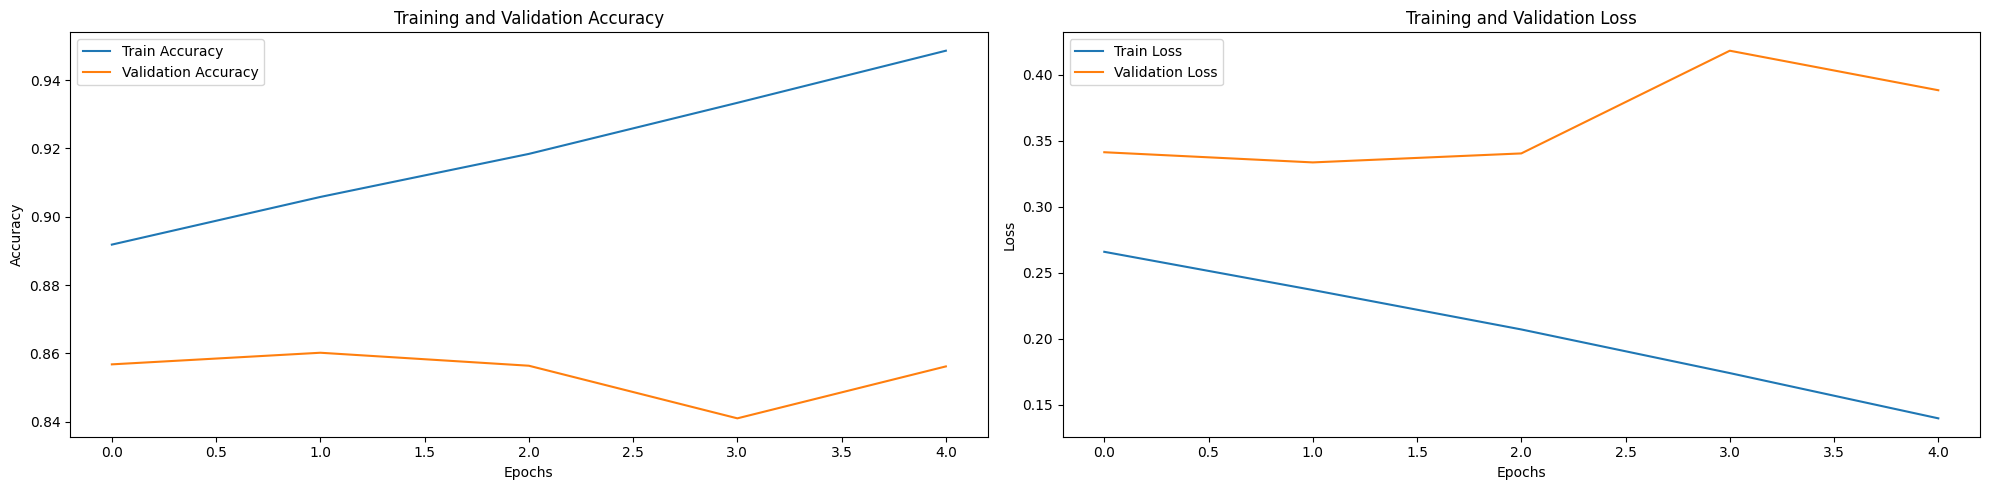

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 5)) # 1 row, 2 columns

# Plotting Accuracy
axes[0].plot(lstm_history.history['accuracy'])
axes[0].plot(lstm_history.history['val_accuracy'])
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend(['Train Accuracy', 'Validation Accuracy'])
axes[0].set_title('Training and Validation Accuracy')

# Plotting Loss
axes[1].plot(lstm_history.history['loss'])
axes[1].plot(lstm_history.history['val_loss'])
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend(['Train Loss', 'Validation Loss'])
axes[1].set_title('Training and Validation Loss')

plt.tight_layout()
plt.show()

In [ ]:
model.fit(X_train,y_train,
          epochs=10,
          initial_epoch=5,
          batch_size=32,
          validation_data=(X_test, y_test))

In [ ]:
model.fit(X_train,y_train,
          epochs=30,
          initial_epoch=10,
          batch_size=32,
          validation_data=(X_test, y_test))

In [1]:
#Bidriectional LSTM

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, BatchNormalization, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.models import Sequential

model = Sequential()

# Input
model.add(Input(shape=(max_review_length,)))

# Frozen embedding layer
model.add(Embedding(input_dim=desired_vocab_size + 1,
                    output_dim=50,
                    weights=[embedding_matrix],
                    trainable=False))

# Normalize embedding features
model.add(BatchNormalization())

# Bidirectional LSTM (forward + backward)
model.add(Bidirectional(LSTM(128)))   # output size will be 256 (128 forward + 128 backward)

# Regularization
model.add(Dropout(0.25))

# Output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])